In [1]:
import numpy as np
import numpy.random as rnd

import scipy as sc
import scipy.linalg as linalg
from scipy import stats

import matplotlib.pyplot as plt

In [2]:
# linear systems 

A = np.array([[1, 1, 0], [0, 1, 6], [5, 5, 5]])
b = np.array([[6], [2], [1]])
B = np.array([[6,3,-6],[12,6,-12],[18,36,-18]])

# solve Ax = b
x = linalg.solve(A, b)

# solve AX = B
X = linalg.solve(A, B)

# inverse of A
A_inv = linalg.inv(A)

# determinant of A
det_A = linalg.det(A)

C = np.array([1, 5, 3, 6])
o1_norm = linalg.norm(C, ord = 1) # sum of absolute values
o2_norm = linalg.norm(C, ord = 2) # square root of sum of squares
# etc
C_min = linalg.norm(C, ord = -np.inf) # min absolute value
C_max = linalg.norm(C, ord = np.inf) # max absolute value

# others: linalg.expm(), linalg.logm()

In [3]:
# SPECTRAL DECOMPOSITION

E = rnd.random((3, 3))
eigval, eigvec = linalg.eig(E)

print(E)
print(eigval)
print(eigvec)

[[0.72228584 0.70125174 0.27507561]
 [0.95634183 0.97031506 0.82880248]
 [0.60947361 0.25766506 0.31907661]]
[1.94479034+0.j         0.03344358+0.24056818j 0.03344358-0.24056818j]
[[ 0.52454889+0.j          0.2078282 -0.47650634j  0.2078282 +0.47650634j]
 [ 0.78830616+0.j          0.20625321+0.53937057j  0.20625321-0.53937057j]
 [ 0.32159269+0.j         -0.62951422+0.j         -0.62951422-0.j        ]]


In [4]:
# SPECIAL MATRICES

# Hadamard
H = linalg.hadamard(n = 2)
# can find full list of special matrices

# to store sparse matrices: sc.sparse.csr_matrix()
# to convert back to dense matrix: A.todense()

# can also first create sparse matrix and then assign values
S = sc.sparse.lil_matrix((4, 4))
S[0, 0] = 1
S[2, 3] = 5
print(S)
print(S.todense())

# sparse also has a lot of functionalities to look up

<List of Lists sparse matrix of dtype 'float64'
	with 2 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	1.0
  (2, 3)	5.0
[[1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 5.]
 [0. 0. 0. 0.]]


In [5]:
# exercise: 5*5 sparse matrix
D = sc.sparse.lil_matrix((5, 5))
D[0, 0] = 1
D[1, 1] = 1
D[2, 2] = 1
D[3, 3] = 1
D[4, 4] = 1
print(D)

# convert to dense
print(D.todense())

diag = np.sum(np.diag(D.todense()))
print(diag)

<List of Lists sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 5)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0
  (4, 4)	1.0
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]
5.0


In [6]:
# MATRIX EXPONENTIAL
n = 4

E = (1 / np.sqrt(n)) * linalg.hadamard(n)
print(E)

expE = linalg.expm(E)
print(expE)

Q = np.round(linalg.expm(A).T,3) == np.round(linalg.expm(A.T),3)
print(Q,'\n')

Q = np.round((np.matrix(linalg.expm(A))).H,3) == np.round(linalg.expm(np.matrix(A).H),3)
print(Q,'\n')

[[ 0.5  0.5  0.5  0.5]
 [ 0.5 -0.5  0.5 -0.5]
 [ 0.5  0.5 -0.5 -0.5]
 [ 0.5 -0.5 -0.5  0.5]]
[[ 2.13068123  0.5876006   0.5876006   0.5876006 ]
 [ 0.5876006   0.95548004  0.5876006  -0.5876006 ]
 [ 0.5876006   0.5876006   0.95548004 -0.5876006 ]
 [ 0.5876006  -0.5876006  -0.5876006   2.13068123]]
[[ True  True  True]
 [ True  True  True]
 [ True  True  True]] 

[[ True  True  True]
 [ True  True  True]
 [ True  True  True]] 



In [7]:
# random unitary

U = stats.unitary_group.rvs(n)
print(np.round(np.dot(U, U.conj().T)))

U = np.matrix(U)
print(np.round(U, 3))
print(np.round(U.H*U))

[[ 1.+0.j -0.-0.j  0.+0.j  0.-0.j]
 [-0.+0.j  1.+0.j  0.-0.j  0.+0.j]
 [ 0.-0.j  0.+0.j  1.+0.j -0.+0.j]
 [ 0.+0.j  0.-0.j -0.-0.j  1.+0.j]]
[[ 0.68 +0.488j  0.187-0.17j   0.22 +0.367j  0.142+0.178j]
 [-0.177+0.356j -0.149+0.07j   0.296-0.544j  0.633+0.173j]
 [ 0.063+0.267j -0.791-0.445j -0.108-0.087j -0.285-0.027j]
 [ 0.187+0.175j  0.251+0.149j  0.267-0.586j -0.654+0.083j]]
[[ 1.+0.j  0.-0.j  0.+0.j  0.-0.j]
 [ 0.+0.j  1.+0.j -0.+0.j -0.+0.j]
 [ 0.-0.j -0.-0.j  1.+0.j -0.+0.j]
 [ 0.+0.j -0.-0.j -0.+0.j  1.+0.j]]


In [8]:
# TENSOR PRODUCT

M = np.array([[1, -2], [-1, 2]])
N = np.array([[1, 2], [3, 4]])

result_dense = sc.sparse.kron(M, N)
print(result_dense.todense())

M = sc.sparse.csr_matrix(M)
N = sc.sparse.csr_matrix(N)
result_sparse = sc.sparse.kron(M, N)
print(result_sparse.todense())

[[ 1  2 -2 -4]
 [ 3  4 -6 -8]
 [-1 -2  2  4]
 [-3 -4  6  8]]
[[ 1  2 -2 -4]
 [ 3  4 -6 -8]
 [-1 -2  2  4]
 [-3 -4  6  8]]


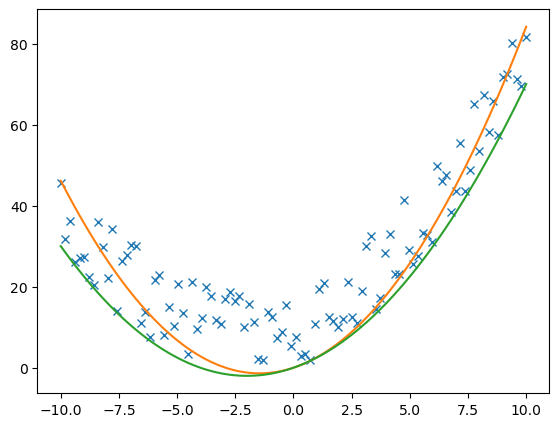

In [9]:
# LEAST SQUARE FIT

# noisy data
c1, c2 = 0.5, 2.0
# x values
x = np.linspace(-10, 10, 100)
# y values without noise 
y = c1 * x ** 2 + c2 * x

# add noise
noise = y + 0.3 * np.max(y) * rnd.random(len(y))
# stack 1D arrays as columns into 2D arrays
A = np.c_[x ** 2, x]

# lstsq to fit noisy data
C, resid, rank, signma = linalg.lstsq(A, noise)
# fitted values
y2 = C[0] * x ** 2 + C[1] * x

fig = plt.figure()
ax = fig.add_axes([.1, .1, .8, .8])
ax.plot(x, noise, "x", x, y2, x, y)
plt.show()

In [10]:
# OTHER MATRIX STUFF IN NOTES
# singular value decomposition
# Schur decomposition

In [11]:
# SCIPY OPTIMIZATION
from scipy import optimize

# function to be minimized
def f(b):
    """
    b: array-like, shape (3,)
    returns float
     """
    return -(.6*np.log(1+b[0]-b[1]-b[2])+.3*np.log(1-b[0]+2*b[1]-b[2])+.1*np.log(1-b[0]-b[1]+4*b[2]))

print(f.__doc__)

from scipy.optimize import Bounds
bounds = Bounds([0, 0, 0], [1, 1, 1]) # bounds inclusive
# initial guess:
initial_guess = np.array([0, 0, 0])
result = optimize.minimize(f, initial_guess, bounds = bounds)

print(result)
# can also find local minima (in notes)
# sc.optimize.fmin(func, initial guess)
# sc.optimize.differential_evolution(func, bounds)


    b: array-like, shape (3,)
    returns float
     
  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: -0.026702217002265195
        x: [ 3.000e-01  1.000e-01  0.000e+00]
      nit: 6
      jac: [ 5.169e-07 -9.506e-08  1.667e-01]
     nfev: 28
     njev: 7
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>


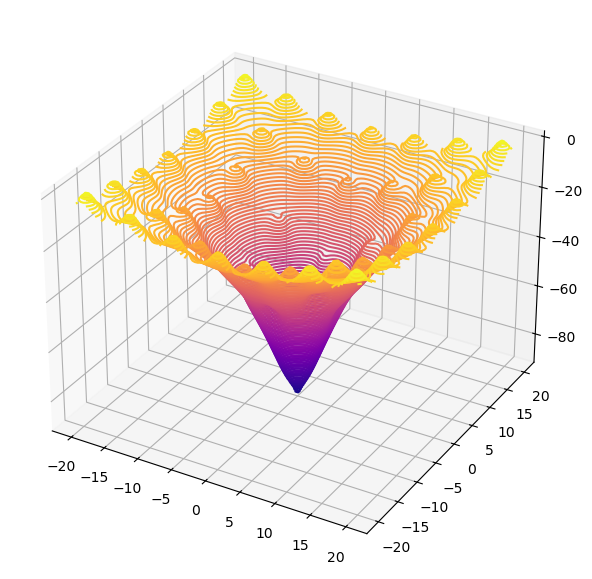

In [12]:
def f(params):
    """
    Function to be minimized.
    
    Returns
    -------
    float
        The computed value of the function at the given input.
    """
    return -100. * np.exp(-0.1*np.sqrt(params[0]**2 + params[1]**2)) + np.exp(np.cos(params[0]) + np.cos(params[1]))

# bounds for x and y  
x_bound = [-20,20]
y_bound = [-20,20]

# meshgrid for plotting
xs = np.linspace(x_bound[0], x_bound[1], 100)
ys = np.linspace(y_bound[0], y_bound[1], 100)

Xmesh,Ymesh = np.meshgrid(xs, ys)
Zmesh = f([Xmesh,Ymesh])

# 3D contour plot
fig = plt.figure(figsize=(7,7))
ax = fig.add_axes([.1,.1,.8,.8],projection='3d')

ax.contour3D(Xmesh,Ymesh,Zmesh,90,cmap='plasma')

plt.show()

In [13]:
# function has many local minima
bounds = [x_bound,y_bound]
result = sc.optimize.differential_evolution(f,bounds)

print(result) # This will print the full result object

print('\nMinimum value found: ',result.fun) # This will print the minimum value found
print('\nParameters at minimum: ',result.x) # Print the parameters at the minimum
print('\nBetter readability by rounding: ',np.round(result.x,2)) # We can round the result for better readability

             message: Optimization terminated successfully.
             success: True
                 fun: -92.61094382476597
                   x: [-5.582e-09 -5.202e-09]
                 nit: 12
                nfev: 498
          population: [[-1.138e-02 -2.197e-02]
                       [-2.922e-02  1.764e-02]
                       ...
                       [-4.794e-03 -1.944e-01]
                       [-2.939e-02  1.072e-01]]
 population_energies: [-9.261e+01 -9.227e+01 ... -9.082e+01 -9.155e+01]
                 jac: [-8.059e-01 -2.692e-01]

Minimum value found:  -92.61094382476597

Parameters at minimum:  [-5.58243540e-09 -5.20177439e-09]

Better readability by rounding:  [-0. -0.]


In [14]:
# sc.optimize.fsolve(func, initial guess) finds roots of the function
# can use two ends of the x range as initial guesses
# roots stored in array

# sc.optimize.curve_fit() perfoms least square fit of a function of data
# (much more on this in notes)

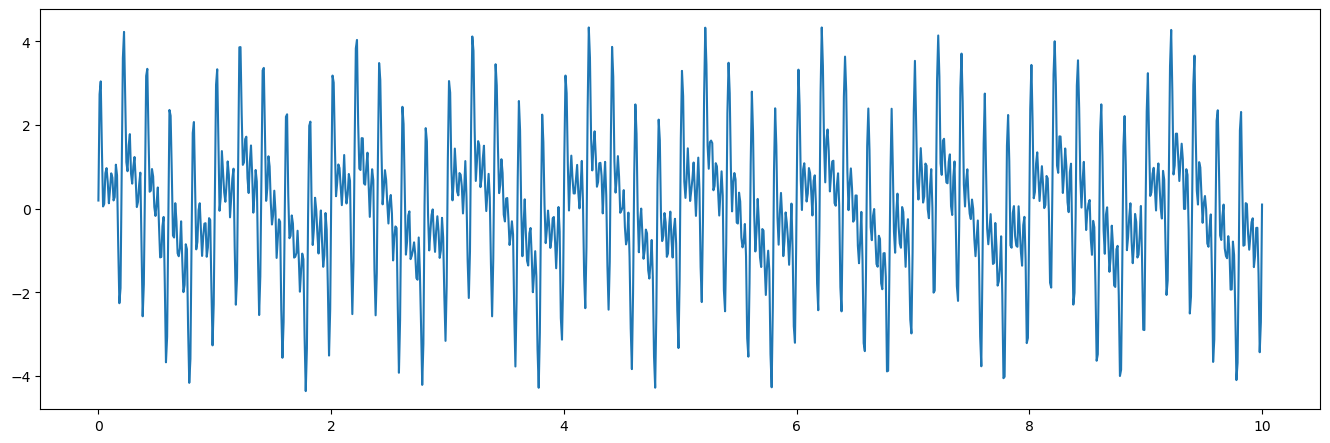

In [15]:
# SCIPY FOURIER TRANSFORM
from scipy.fft import fft, fftfreq, fftshift

# create signal made up of many sine waves 
steps = 1000
t = np.linspace(0, 10, steps)
w = [1, 5, 10, 15, 20]

# create noisy signal
noise = 0.5 * rnd.random(steps) - 0.25

# combine sine wave and noise 
signal = 0
for i in w:
    signal += np.sin(i * t * 2 * np.pi)
signal += noise

# plot 
fig = plt.figure(figsize = (16, 5))
ax = fig.add_axes([.1, .1, .8, .8])
ax.plot(t, signal)
plt.show()

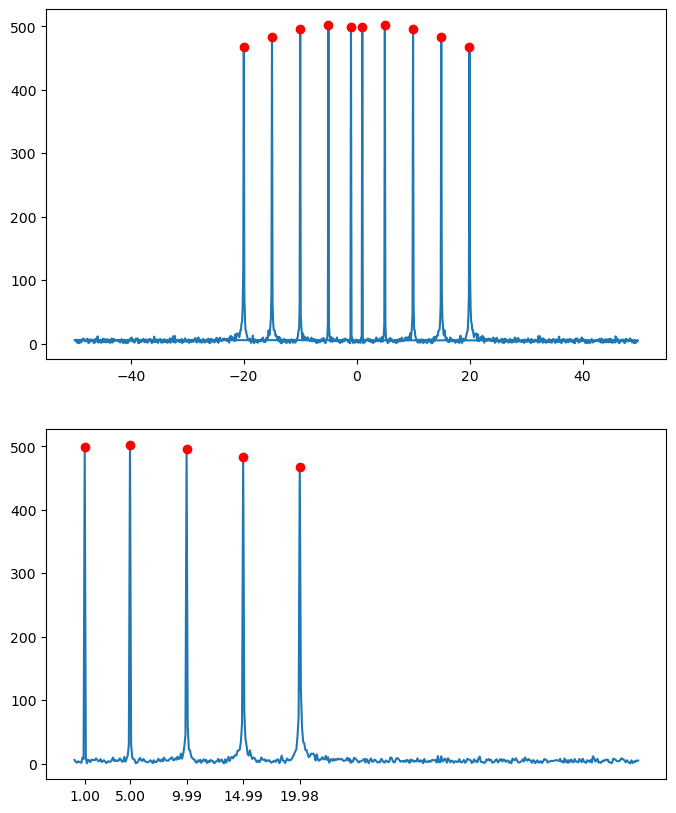

Peak frequencies:  [ 0.999  4.995  9.99  14.985 19.98 ]


In [16]:
# number of sample points
n = len(t)
# sample spacing 
h = t[1] - t[0]

# compute Fourier Transform
Fourier = fft(signal)
freq = fftfreq(n, h)

# plot
fig, ax = plt.subplots(2, 1, figsize = (8, 10))
ax[0].plot(freq, abs(Fourier), freq[abs(Fourier) > 300], abs(Fourier)[abs(Fourier) > 300], "ro")
# select only positive frequencies for better visualisation
positive = freq > 0
freq = freq[positive]
Fourier = Fourier[positive]
ax[1].plot(freq, abs(Fourier), freq[abs(Fourier) > 300], abs(Fourier)[abs(Fourier) > 300], "ro")
ax[1].set_xticks(freq[abs(Fourier) > 300])

plt.show()

print("Peak frequencies: ", freq[abs(Fourier) > 300])

Omega =  8.0


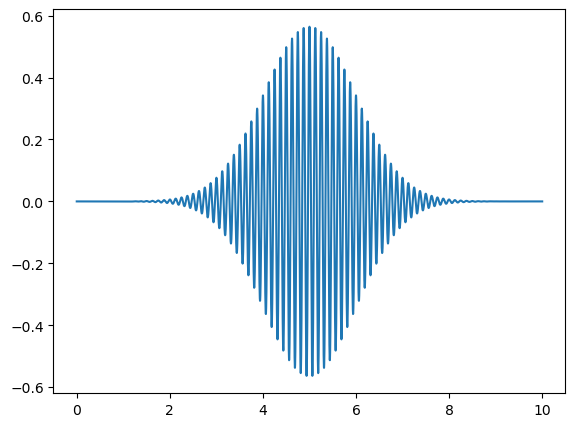

Omega =  8.0


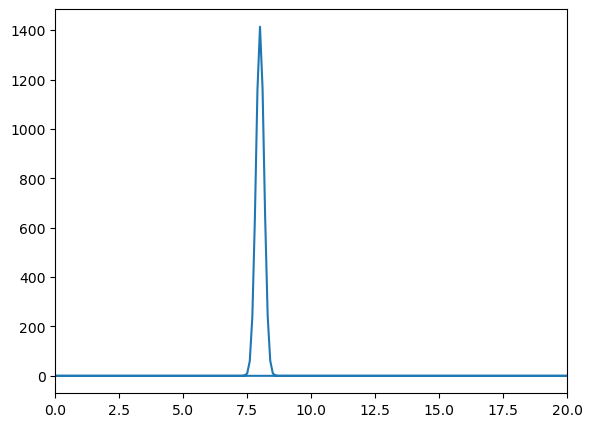

In [17]:
# can do the same with a wave packet (in notes)

# exercise
def wavepacket(sigma, f):
    """
    sigma: width of wave packet
    f: frequency of wave packet
    """
    steps = 10000
    x = np.linspace(0, 10, steps)
    h = x[1] - x[0]
    n = len(x)

    f = f * 2 * np.pi
    print("Omega = ", f / (2 * np.pi))

    x_0 = 5
    packet = (1 / (sigma * np.sqrt(np.pi))) * np.exp(-(x - x_0) ** 2 / (2 * sigma ** 2)) * np.exp(1j * f * x)

    fig_1 = plt.figure()
    ax1 = fig_1.add_axes([.1, .1, .8, .8])
    ax1.plot(x, packet.real)
    plt.show()

    Fourier = fft(packet)
    freq = fftfreq(n, h)

    print("Omega = ", f / (2 * np.pi))
    m = abs(Fourier) >= max(abs(Fourier))

    fig_2 = plt.figure()
    ax2 = fig_2.add_axes([.1, .1, .8, .8])
    ax2.plot(freq, abs(Fourier))
    ax2.set_xlim(0, 20)

    plt.show()

wavepacket(1, 8)

In [18]:
# Quantum Fourier Transform

# define qubit
n = 2
x0 = 0
x1 = 1
# create the state vector 
x = np.array([x0, x1])
# normalise
x = x / np.sqrt(np.dot(x.conj().T, x))

# Apply Fourier Transform 
y = 1 / np.sqrt(n) * fft(x)

print(x, abs(x)**2, y, abs(y)**2)

# multiple qubits in notes
# how to plot in bloch sphere in notes

[0. 1.] [0. 1.] [ 0.70710678+0.j -0.70710678-0.j] [0.5 0.5]


Area = 4.32808512266689
Error = 4.805139755722376e-14


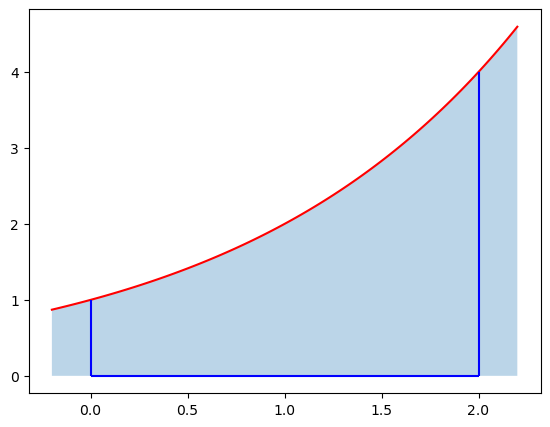

In [19]:
# Scipy ODE's and PDE's
from matplotlib import animation
from IPython.display import HTML
import numpy.random as rnd
from scipy import integrate

# Integration 
def f(x):
    return 2 ** x

a = 0
b = 2
def_int, err = integrate.quad(f, a, b)
print(f"Area = {def_int}")
print(f"Error = {err}")

# make plot
x = np.linspace(a - .2, b + .2, 100) 
fig = plt.figure()
ax = fig.add_axes([.1, .1, .8, .8])
ax.plot(x, f(x), "r")

ax.vlines([a, b], [0, 0], [f(a), f(b)], "b")
ax.hlines(0, a, b, "b")
ax.fill_between(x, f(x), alpha = 0.3)

plt.show()

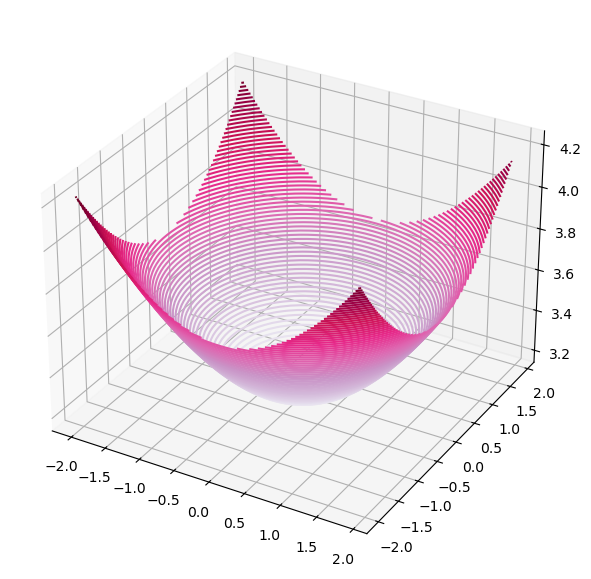

In [20]:
# integration over two variables
def g(x, y):
    return np.sqrt(x ** 2 + y ** 2 + 10)

# integration limits
a = -2
b = 2
c = -2
d = 2

def_int, err = integrate.dblquad(g, a, b, c, d)
x = np.arange(a, b, .1)
y = np.arange(c, d, .1)

Xmesh, Ymesh = np.meshgrid(x, y)
Zmesh = g(Xmesh, Ymesh)
fig = plt.figure(figsize = (7, 7))
ax = fig.add_axes([.1, .1, .8, .8], projection = "3d")
ax.contour3D(Xmesh, Ymesh, Zmesh, 90, cmap = "PuRd")

plt.show()

# integrate.tplquad(h, a, b, c, d, e, f)

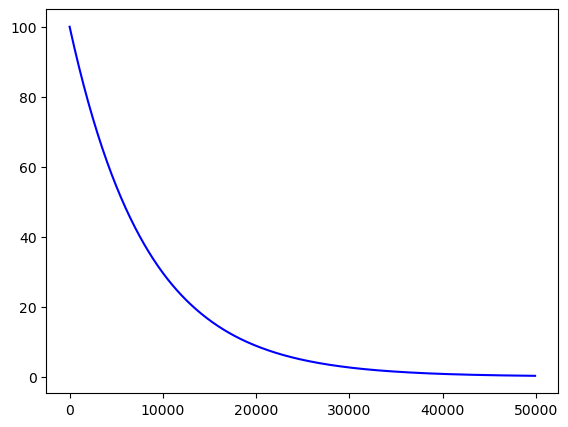

In [21]:
# ODEs
# example: radioactive decay

# decay constant
k = -0.0001216

def exponential_decay(t, y):
    return k * y

# define time points where we want the solution
t = np.arange(0, 50000, 100)
sol = integrate.solve_ivp(exponential_decay, [0, 50000], [100], t_eval = t)

fig = plt.figure()
ax = fig.add_axes([1., .1, .8, .8])
ax.plot(sol.t, sol.y[0, :], "b")
plt.show()

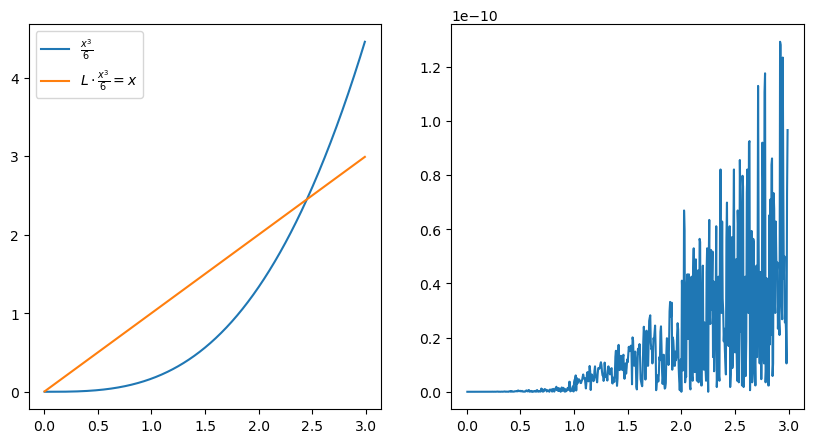

In [22]:
# FINITE DIFFERENCE METHOD

# define spatial step size and spatial grid
h = 0.005
x = np.arange(0, 3, h)
size = x.size
# create second derivative operator using finite differences
L = sc.sparse.diags([1, -2, 1], [-1, 0, 1], shape = (size, size)) / h ** 2
error = abs(x[1:-1]-L.dot((x ** 3) / 6)[1:-1])

fig = plt.figure(figsize = (10, 5))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

ax1.plot(x[1:-1], ((x ** 3) / 6)[1:-1], label = r"$\frac{x^3}{6}$")
ax1.plot(x[1:-1], L.dot(((x ** 3) / 6))[1:-1], label = r"$L \cdot \frac{x^3}{6} = x$")
ax2.plot(x[1:-1], error)
ax1.legend()

plt.show()

In [23]:
L_dense = L.todense()
print(L_dense)

[[-80000.  40000.      0. ...      0.      0.      0.]
 [ 40000. -80000.  40000. ...      0.      0.      0.]
 [     0.  40000. -80000. ...      0.      0.      0.]
 ...
 [     0.      0.      0. ... -80000.  40000.      0.]
 [     0.      0.      0. ...  40000. -80000.  40000.]
 [     0.      0.      0. ...      0.  40000. -80000.]]


In [24]:
# Partial differential equations (PDEs)

# example: QUANTUM HARMONIC OSCILLATOR

#initialise discrete spatial points into array
h = 0.005
x = np.arange(-10, 10, h)
size = x.size

# define laplace operator
L = sc.sparse.diags([1, -2, 1], [-1, 0, 1], shape = (size, size)) / h ** 2

# initialise parameters values and potential V
hbar = 1
m = 1
w = 2 * np.pi 
a = 0 
V = 0.5 * m * (w ** 2) * (x - a) ** 2

# define function to be integrated
def wave_fn(t, psi):
    return -1j * (- (hbar / (2 * m)) * L.dot(psi) + (V / hbar) * psi)

# time range for integration
t_eval = np.arange(0, 1, h)

# initial state psi as wavepacket
f = 8 * (2 * np.pi)
sigma = 1
x0 = a
packet = (1 / (sigma * np.sqrt(np.pi))) * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2)) * np.exp(1j * f * x)
# normalise
packet = packet / (np.sqrt(sum((abs(packet)) ** 2)))

# solve
sol = sc.integrate.solve_ivp(wave_fn, t_span = [0, 1], y0 = packet, t_eval = t_eval)

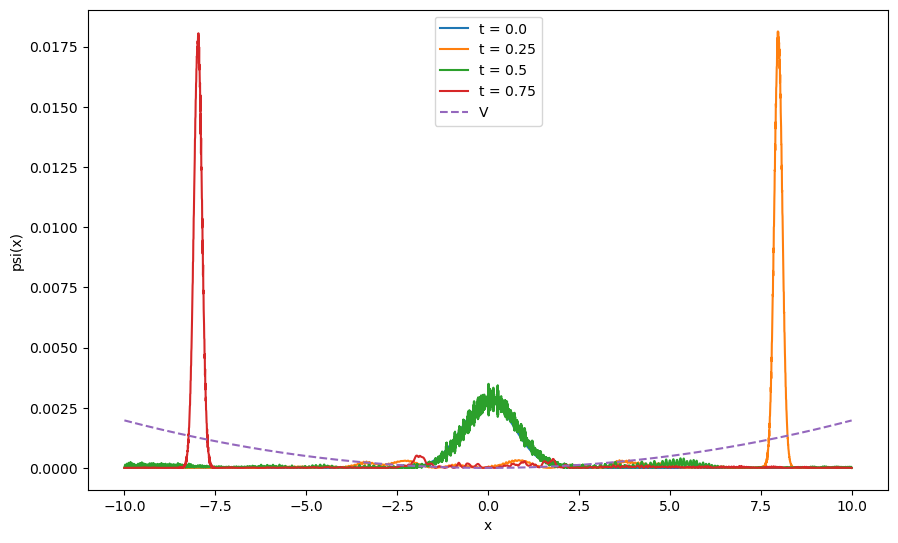

In [25]:
# plotting
fig = plt.figure(figsize = (10, 6))
ax = fig.add_axes([.1, .1, .8, .8])

for i, t in enumerate(sol.t):
    if i % 50 == 0:
        ax.plot(x, np.abs(sol.y[:, i]) ** 2, label = "t = {}".format(t))

# plot potential, adjusting size for visual aid
ax.plot(x, V * 0.000001, "--", label = "V")
ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("psi(x)")
plt.show()

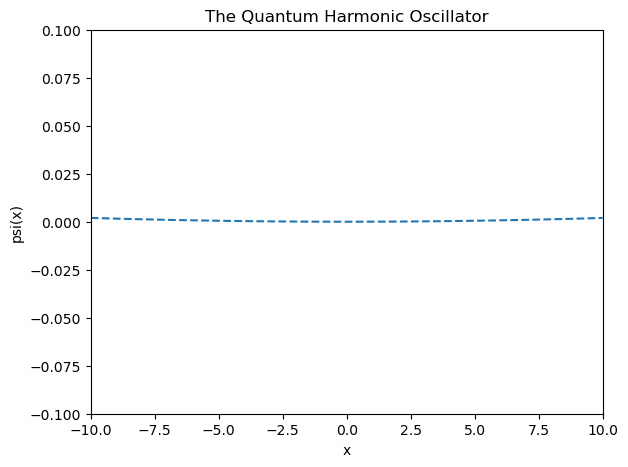

In [27]:
%matplotlib inline
from matplotlib.animation import FuncAnimation

fig = plt.figure()
ax1 = fig.add_axes([.1, .1, .8, .8])

ax1.set_xlim(-10, 10)
ax1.set_ylim(-0.1, 0.1)
ax1.set_xlabel("x")
ax1.set_ylabel("psi(x)")

title = ax1.set_title("The Quantum Harmonic Oscillator")
line1, = ax1.plot([], [], "--")
line2, = ax1.plot([], [], color = "red")

def init():
    """
    initialise animation background
    """
    line1.set_data(x, V * 0.000001)
    return line1,

def animate(i):
    """
    perform animation step
    """
    line2.set_data(x, sol.y[:, i])
    title.set_text("t = {0:1.3f".format(sol.t[i]))

anim = FuncAnimation(fig, animate, init_func = init, frames = len(sol.t), interval = 50, blit = True)

plt.show()

In [32]:
# apply fourier transform to see frequency components of wavefunction at different times
from numpy.fft import fftfreq
from scipy import fftpack 

F = fftpack.fft(sol.y[:, 0])
w = fftfreq(size, h)
F = F / (np.sqrt(sum((abs(F)) ** 2)))

# select only positive frequencies
indices = w > 0
w_pos = w[indices]
F_pos = F[indices]

fig, ax = plt.subplots(figsize = (9, 3))
ax.plot(w_pos, abs(F_pos))
ax.set_xlim(0, 10)

(0.0, 10.0)

In [49]:
# step potential and quanutm tunneling

h = 0.005
x = np.arange(0, 10, h)
size = x.size

L0 = sc.sparse.diags([1, -2, 1], [-1, 0, 1], shape = (size, size)) / h ** 2

hbar = 1 
m = 1

# centre of V(x)
x_Vmin = 5
T = 1
omega = 2 * np.pi / T
k = omega ** 2 * m
V = np.zeros(size)
V[int(V.size / 2) : ] = x_Vmin * 250

def psi_t(t, psi):
    return -1j * (0.5 * hbar / m * L0.dot(psi) + V / hbar * psi)

dt = 0.001
t0 = 0.0
tf = 0.2
t_eval = np.arange(t0, tf, dt)

sigma = 0.5
x0 = 3
kx = 50
A = 1 / (sigma * np.sqrt(np.pi))
psi0 = np.sqrt(A) * np.exp(-(x - x0) ** 2 / (2 * sigma ** 2)) * np.exp(1j * kx * x)

# solve initial value problem
sol = integrate.solve_ivp(psi_t, t_span = [t0, tf], y0 = psi0, t_eval = t_eval)

In [55]:
import matplotlib as mpl
%matplotlib inline
mpl.use("TkAgg")

fig = plt.figure()
ax1 = plt.subplot(1, 1, 1)
ax1.set_xlim(0, 10)
ax1.set_ylim(-6, 6)
line1, = ax1.plot([], [], "k--")
line2, = ax1.plot([], [])

def init():
    line1.set_data(x, V * 0.001)
    return line1,

def animate(i):
    line2.set_data(x, (sol.y[:, i]).real)
    return line2,

anim = FuncAnimation(fig, animate, init_func = init, frames = len(sol.t), interval = 50, blit = True)
plt.show()